# Detecting Insurance Fraud Using Logistic Regression

This project focuses on identifying fraudulent insurance claims using logistic regression, a fundamental yet powerful classification technique. The dataset contains 1,000 records with both numerical and categorical features describing policy details, customer demographics, and incident characteristics. The workflow begins with data inspection and cleaning (checking for missing values, duplicates, and data types) to ensure the dataset is suitable for modeling. This analysis lays the groundwork for building a predictive model that distinguishes between legitimate and fraudulent claims, providing insights into patterns that signal potential fraud.

# Environment Setup and Data Import

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [37]:
df = pd.read_csv(r'/content/insurance_fraud_cleaned.csv')
df

,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,...,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,auto_make,auto_year,fraud_reported
0,328,48,OH,250/500,1000,1406.91,0,MALE,MD,craft-repair,...,SC,5,1,YES,1,2,YES,Saab,2004,Y
1,228,42,IN,250/500,2000,1197.22,5000000,MALE,MD,machine-op-inspct,...,VA,8,1,?,0,0,?,Mercedes,2007,Y
2,134,29,OH,100/300,2000,1413.14,5000000,FEMALE,PhD,sales,...,NY,7,3,NO,2,3,NO,Dodge,2007,N
3,256,41,IL,250/500,2000,1415.74,6000000,FEMALE,PhD,armed-forces,...,OH,5,1,?,1,2,NO,Chevrolet,2014,Y
4,228,44,IL,500/1000,1000,1583.91,6000000,MALE,Associate,sales,...,NY,20,1,NO,0,1,NO,Accura,2009,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,OH,500/1000,1000,1310.80,0,FEMALE,Masters,craft-repair,...,NC,20,1,YES,0,1,?,Honda,2006,N
996,285,41,IL,100/300,1000,1436.79,0,FEMALE,PhD,prof-specialty,...,SC,23,1,YES,2,3,?,Volkswagen,2015,N
997,130,34,OH,250/500,500,1383.49,3000000,FEMALE,Masters,armed-forces,...,NC,4,3,?,2,3,YES,Suburu,1996,N
998,458,62,IL,500/1000,2000,1356.92,5000000,MALE,Associate,handlers-cleaners,...,NY,2,1,?,0,1,YES,Audi,1998,N


# Data Exploration and Feature Selection

This section explores the dataset in depth to understand variable distributions, relationships, and potential predictors of insurance fraud. Through univariate, bivariate, and multivariate analyses, key patterns and correlations are identified. Statistical tools such as VIF, correlation heatmaps, and hierarchical clustering are used to detect multicollinearity and redundancy.
Based on these insights, non-informative or overlapping variables are removed, resulting in a refined set of independent, meaningful features ready for logistic regression modeling.

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_state                 1000 non-null   object 
 3   policy_csl                   1000 non-null   object 
 4   policy_deductable            1000 non-null   int64  
 5   policy_annual_premium        1000 non-null   float64
 6   umbrella_limit               1000 non-null   int64  
 7   insured_sex                  1000 non-null   object 
 8   insured_education_level      1000 non-null   object 
 9   insured_occupation           1000 non-null   object 
 10  insured_relationship         1000 non-null   object 
 11  capital-gains                1000 non-null   int64  
 12  capital-loss                 1000 non-null   int64  
 13  incident_date      

In [39]:
df.dtypes.value_counts()


,count
object,16
int64,11
float64,1


In [40]:
print("Dataset shape:", df.shape)

Dataset shape: (1000, 28)


In [41]:
print(df.isnull().any(axis=0))


months_as_customer             False
age                            False
policy_state                   False
policy_csl                     False
policy_deductable              False
policy_annual_premium          False
umbrella_limit                 False
insured_sex                    False
insured_education_level        False
insured_occupation             False
insured_relationship           False
capital-gains                  False
capital-loss                   False
incident_date                  False
incident_type                  False
collision_type                 False
incident_severity              False
authorities_contacted           True
incident_state                 False
incident_hour_of_the_day       False
number_of_vehicles_involved    False
property_damage                False
bodily_injuries                False
witnesses                      False
police_report_available        False
auto_make                      False
auto_year                      False
f

In [42]:
df['authorities_contacted'].value_counts()

,count
authorities_contacted,
Police,292
Fire,223
Other,198
Ambulance,196


In [43]:
df['authorities_contacted'] = df['authorities_contacted'].fillna('None')
print(df['authorities_contacted'].value_counts(dropna=False))

authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
None          91
Name: count, dtype: int64


In [44]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)


Index(['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_relationship', 'incident_date',
       'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'property_damage',
       'police_report_available', 'auto_make', 'fraud_reported'],
      dtype='object')


In [45]:
from sklearn.preprocessing import LabelEncoder

df_numeric = df.copy()

categorical_cols = df_numeric.select_dtypes(include='object').columns

le = LabelEncoder()
for col in categorical_cols:
    df_numeric[col] = le.fit_transform(df_numeric[col])

df_numeric.head()

,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,...,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,auto_make,auto_year,fraud_reported
0,328,48,2,1,1000,1406.91,0,1,4,2,...,4,5,1,2,1,2,2,10,2004,1
1,228,42,1,1,2000,1197.22,5000000,1,4,6,...,5,8,1,0,0,0,0,8,2007,1
2,134,29,2,0,2000,1413.14,5000000,0,6,11,...,1,7,3,1,2,3,1,4,2007,0
3,256,41,0,1,2000,1415.74,6000000,0,6,1,...,2,5,1,0,1,2,1,3,2014,1
4,228,44,0,2,1000,1583.91,6000000,1,0,11,...,1,20,1,1,0,1,1,0,2009,0


All categorical variables were encoded into numeric IDs using label encoding. The transformation preserved category counts, ensuring no data loss, and represents categories as nominal (not ordinal) values.

[Text(0, 0, '753'), Text(0, 0, '247')]

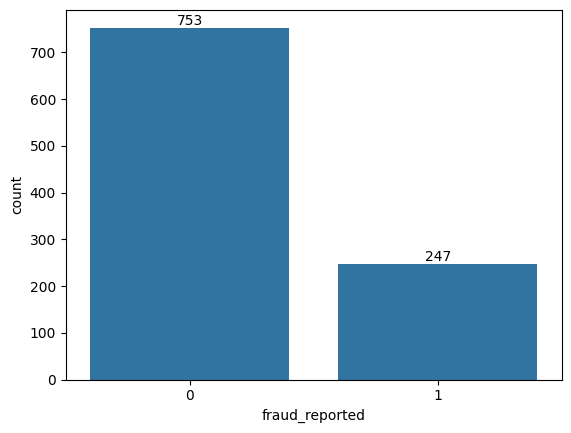

In [46]:
ax=sns.countplot(data=df_numeric, x='fraud_reported');
ax.bar_label(ax.containers[0])

<Figure size 640x480 with 0 Axes>

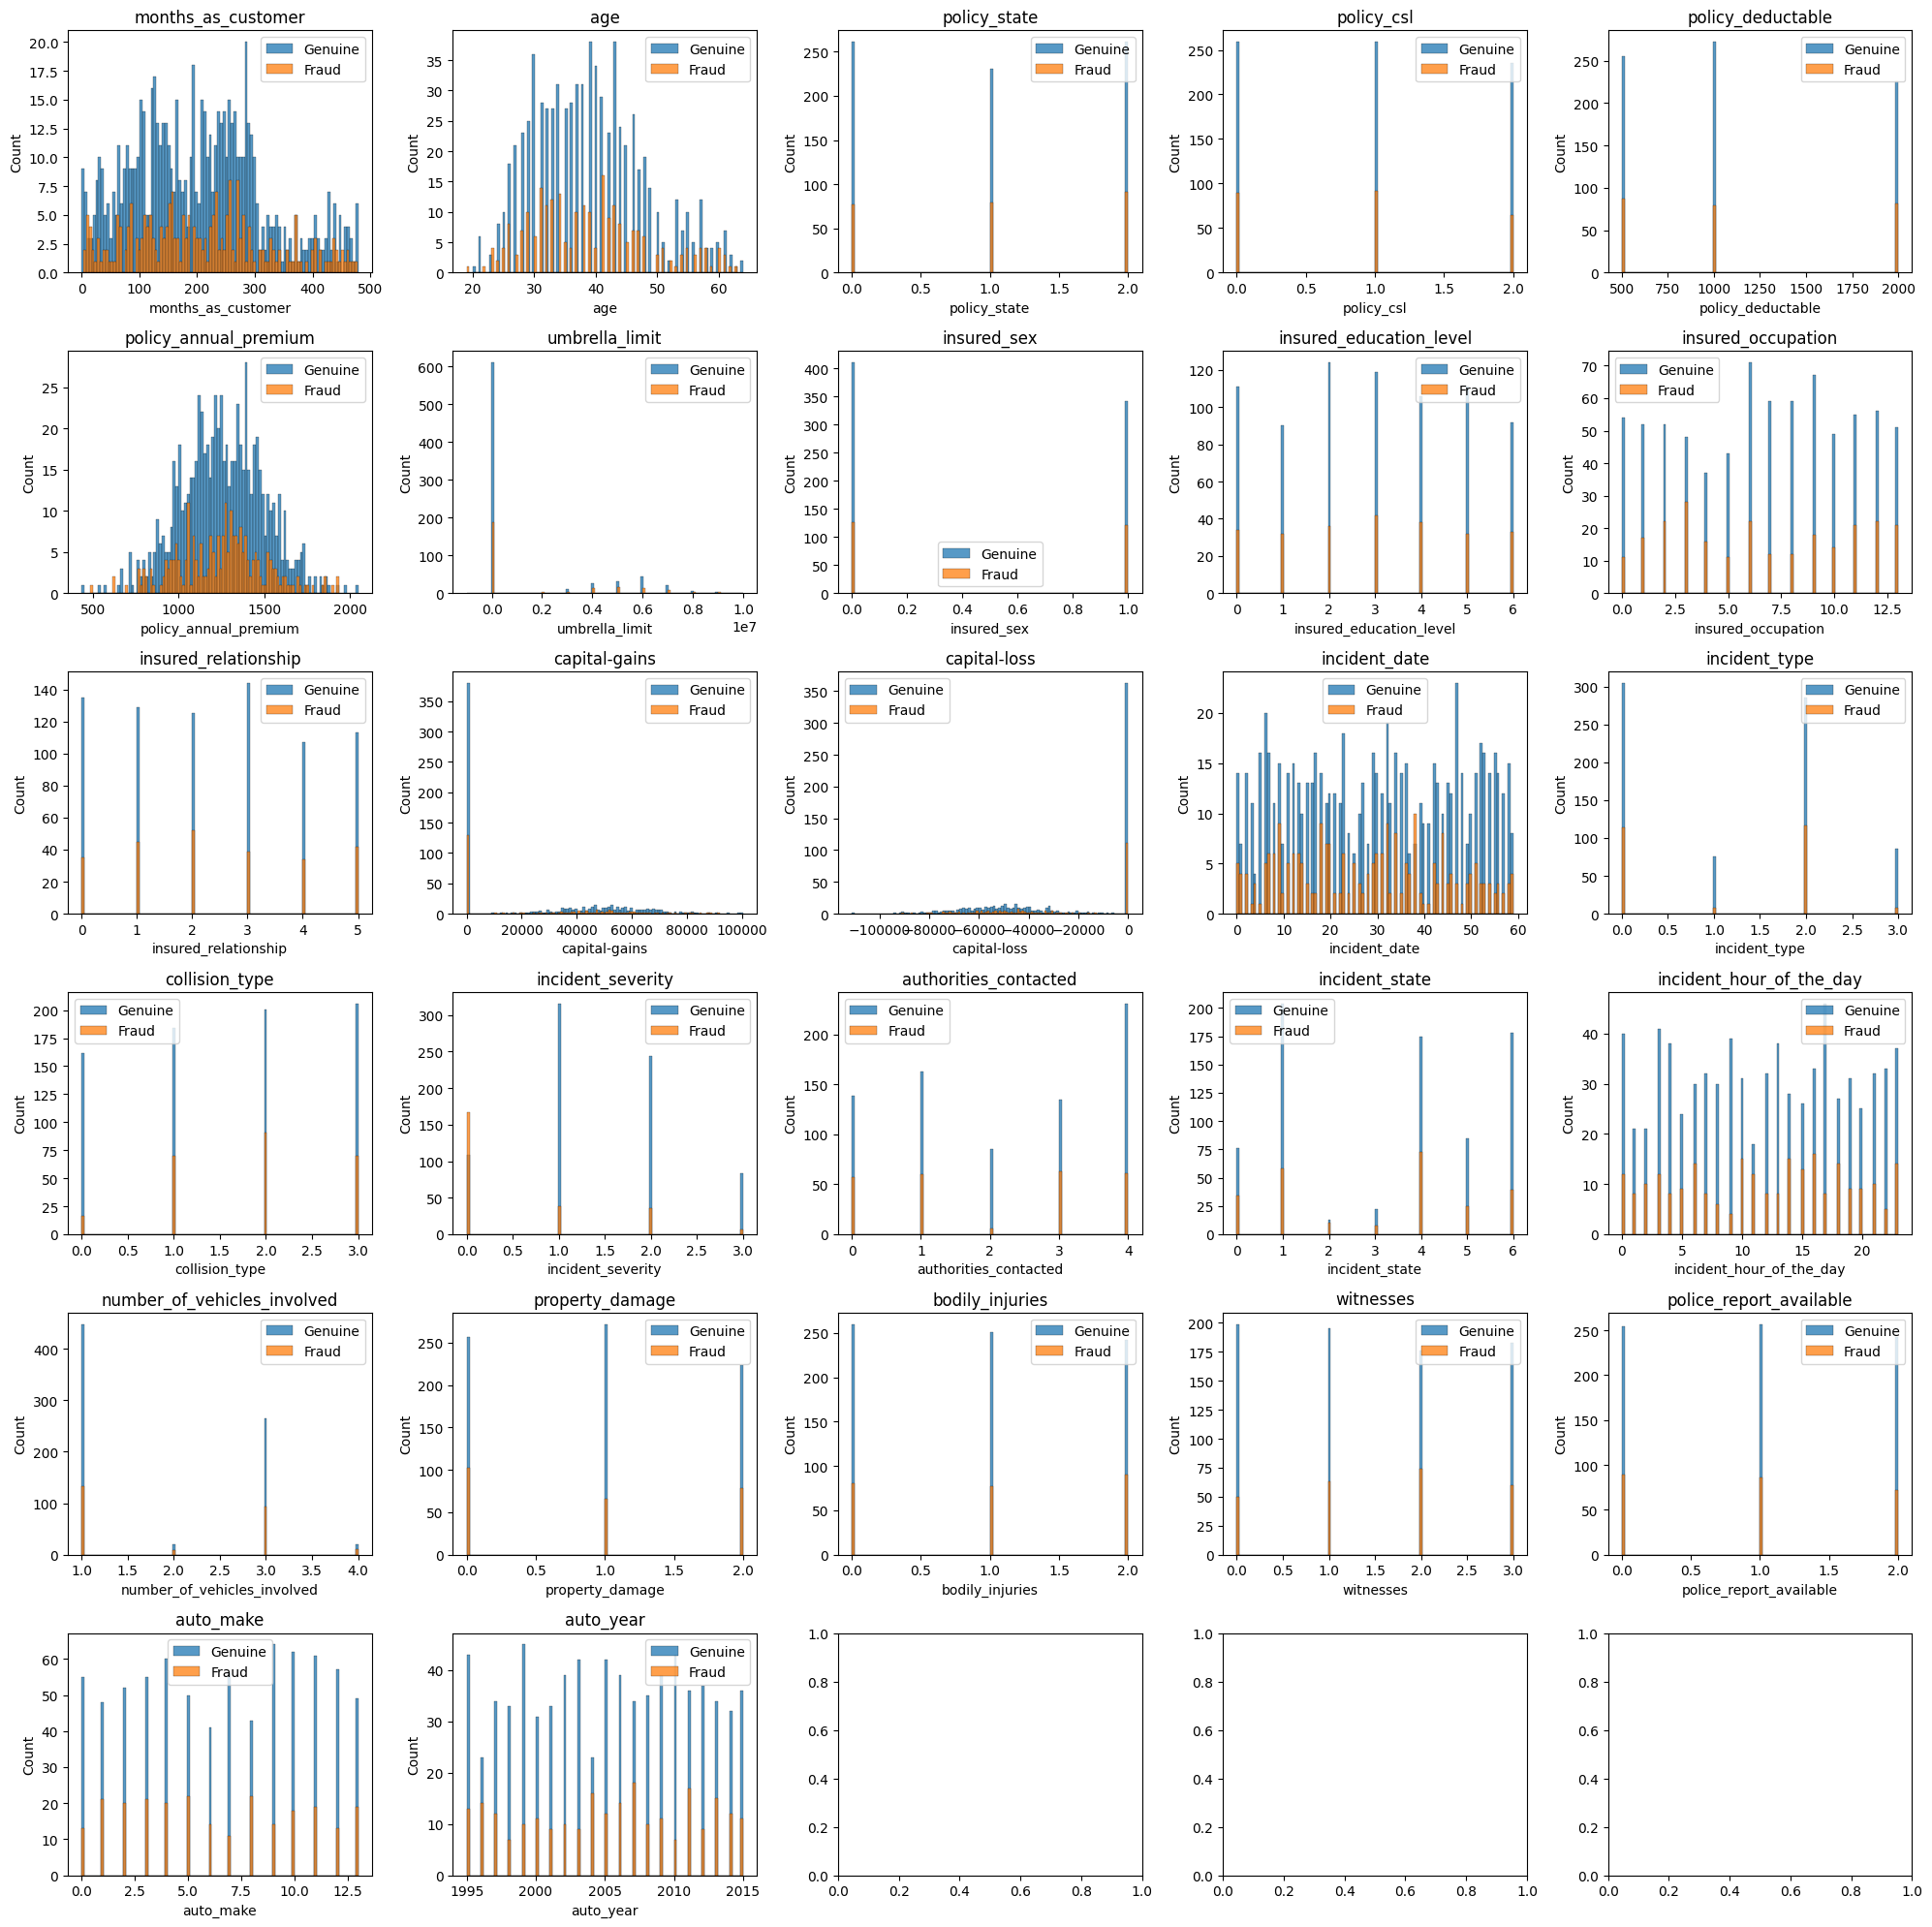

In [47]:
plt.figure()
fig, ax = plt.subplots(6,5,figsize=(20, 20))
i = 0
for feature in df_numeric.columns[:-1]:
  i += 1
  plt.subplot(6,5,i)
  sns.histplot(df_numeric[df_numeric['fraud_reported']==0][feature], bins=100, label="Genuine")
  sns.histplot(df_numeric[df_numeric['fraud_reported']==1][feature], bins=100, label="Fraud")
  plt.title(feature)
  plt.legend()
fig.tight_layout()
plt.show()

Each plot compares feature distributions for fraudulent (orange) and genuine (blue) claims. This helps identify variables that differ meaningfully between the two groups.

Key Patterns

* Strong signals: incident_severity, property_damage, police_report_available, authorities_contacted, and collision_type show clear separation between fraud and genuine claims.

* Moderate signals: incident_hour_of_the_day, incident_state, insured_occupation, and insured_relationship display partial distinctions.

* Weak or neutral: Variables like months_as_customer, age, policy_state, and auto_year show overlapping distributions and are likely weak predictors.

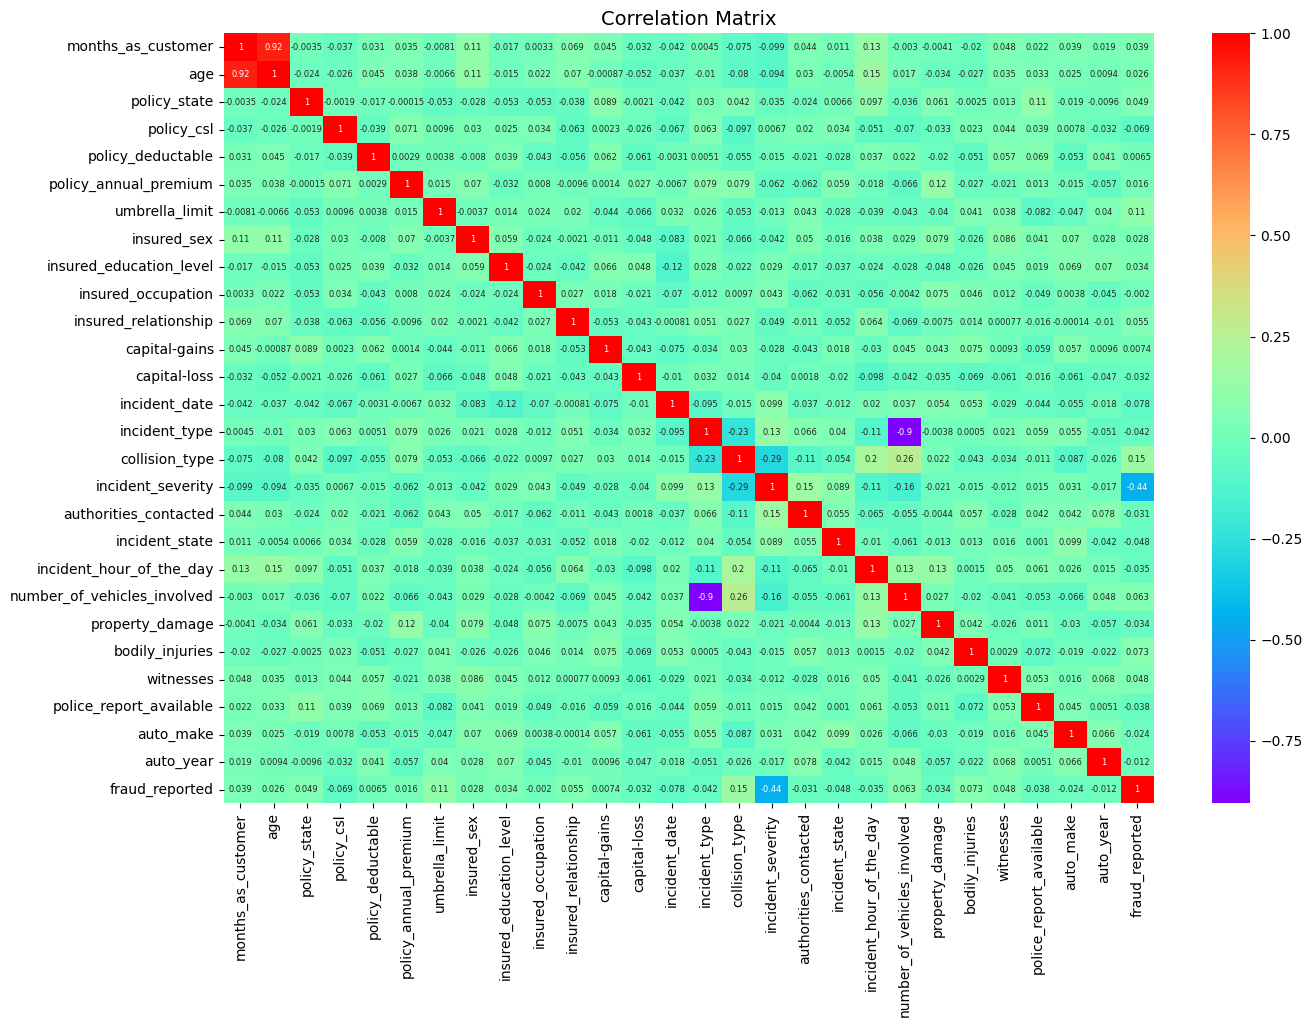

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

plt.figure(figsize=(15, 10))

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(df_numeric[df_numeric.columns[:-1]], df_numeric["fraud_reported"])

df_numeric_balanced = pd.concat([pd.DataFrame(X_res, columns=df_numeric.columns[:-1]),
                         pd.Series(y_res, name="fraud_reported")], axis=1)

corr = df_numeric_balanced.corr()

sns.heatmap(corr, annot=True, annot_kws={'size': 6}, cmap='rainbow')
plt.title("Correlation Matrix", fontsize=14)
plt.show()


The heatmap shows pairwise correlations between all features. Most values fall between –0.1 and +0.1, indicating low multicollinearity, ideal for logistic regression.

Key relationships:

* months_as_customer ↔ age: strongly correlated (~0.92), suggesting redundancy.

* incident_severity ↔ collision_type: moderate negative correlation (~–0.44).

* incident_hour_of_the_day ↔ number_of_vehicles_involved: weak relationship (~0.1).

fraud_reported shows small correlations (0.02–0.11), typical for categorical targets.

/tmp/ipython-input-3566675543.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')


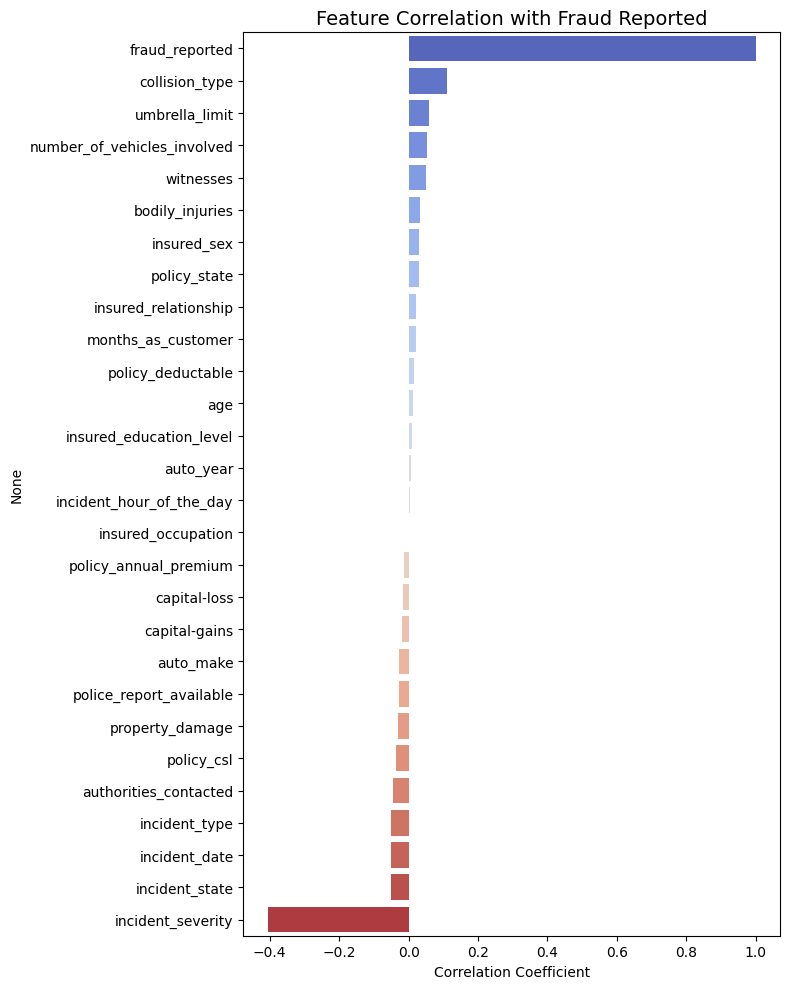

In [49]:
plt.figure(figsize=(8, 10))
corr_target = df_numeric.corr()['fraud_reported'].sort_values(ascending=False)
sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')
plt.title("Feature Correlation with Fraud Reported", fontsize=14)
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

This bar chart shows each feature’s Pearson correlation with the target (fraud_reported).
Positive values indicate a higher likelihood of fraud, while negative values suggest the opposite.

Key patterns:

* Strongest signal: incident_severity has a clear negative correlation (~–0.4), meaning lower-severity incidents are more often fraudulent.

* Moderate positives: collision_type, umbrella_limit, number_of_vehicles_involved, and witnesses show small positive links to fraud.

* Mostly neutral: Features like insured_sex, policy_state, insured_relationship, and age have near-zero correlations.

* Slight negatives: A few variables (e.g., incident_state, authorities_contacted, policy_csl) show weak negative associations.

In [50]:

corr_matrix = df_numeric.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
print("Highly correlated features to drop:", to_drop)


Highly correlated features to drop: ['age', 'number_of_vehicles_involved']


In [51]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df_numeric.drop(columns=['fraud_reported']).copy()

X_vif = X_vif.assign(constant=1)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

vif_data = vif_data.sort_values(by="VIF", ascending=False)
print(vif_data)


                        Feature            VIF
27                     constant  114943.488172
1                           age       6.777525
0            months_as_customer       6.758914
14                incident_type       5.123061
20  number_of_vehicles_involved       5.111969
15               collision_type       1.286708
16            incident_severity       1.145612
19     incident_hour_of_the_day       1.086943
17        authorities_contacted       1.064985
10         insured_relationship       1.030522
18               incident_state       1.030203
26                    auto_year       1.029928
5         policy_annual_premium       1.029845
11                capital-gains       1.029651
21              property_damage       1.028922
12                 capital-loss       1.028767
25                    auto_make       1.028641
13                incident_date       1.028315
23                    witnesses       1.027056
6                umbrella_limit       1.025530
4            

Variance Inflation Factor (VIF) was used to detect multicollinearity among features.

* VIF < 5: No concern = keep the feature.

* 5–10: Moderate correlation = consider reviewing.

* '>10': High multicollinearity = drop the feature.

Findings:

* The intercept’s high VIF (~114,943) is normal and ignored.

* Moderate VIFs were found for age (6.78), months_as_customer (6.76), incident_type (5.12), and number_of_vehicles_involved (5.11).

* age and number_of_vehicles_involved were dropped as redundant, while months_as_customer and incident_type were retained since their VIFs will fall after removal.

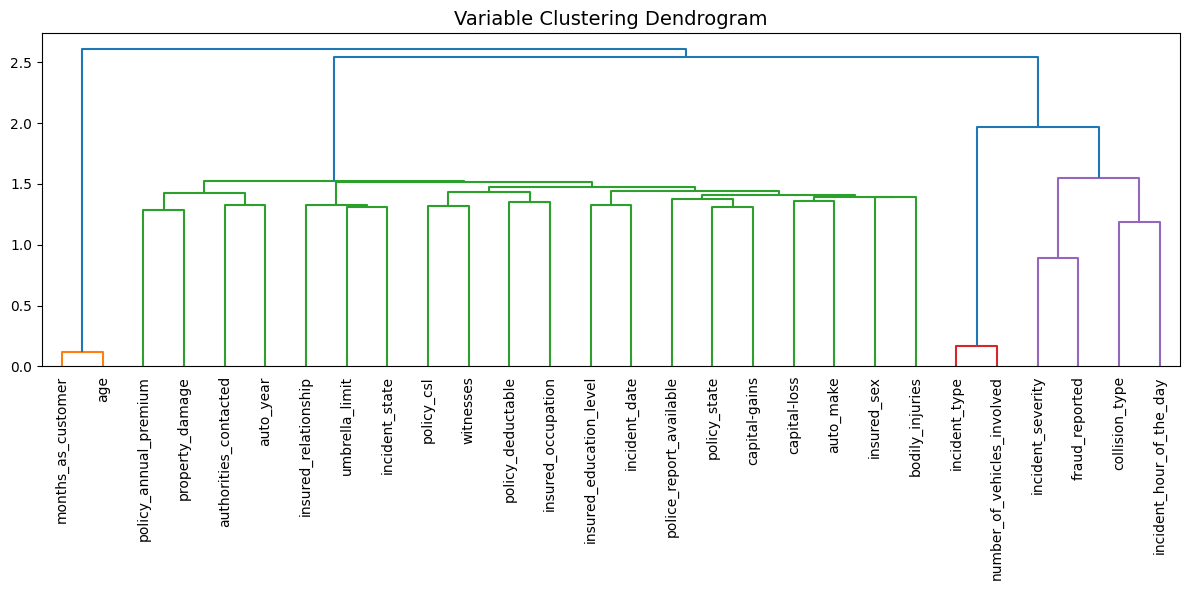

In [52]:
from scipy.cluster.hierarchy import linkage, dendrogram

corr = df_numeric.corr().abs()

link = linkage(corr, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(link, labels=corr.columns, leaf_rotation=90)
plt.title("Variable Clustering Dendrogram", fontsize=14)
plt.tight_layout()
plt.show()


The dendrogram groups features based on their pairwise correlations, branches closer together indicate stronger relationships.

Key clusters:

* Cluster 1: months_as_customer and age are nearly identical, confirming earlier correlation and VIF findings. → Keep one (months_as_customer).

* Cluster 2: Features like policy_annual_premium, umbrella_limit, policy_deductible, and demographic attributes form a loose group, showing mild correlations. → All can be retained.

* Cluster 3: Event-related variables: incident_type, incident_severity, collision_type, and incident_hour_of_the_day cluster together, reflecting shared context around each claim. → Keep all except number_of_vehicles_involved, already removed as redundant.

In [53]:
from scipy.cluster.hierarchy import fcluster

max_d = 1.5

clusters = fcluster(link, max_d, criterion='distance')

cluster_df = pd.DataFrame({'Feature': corr.columns, 'Cluster': clusters})
cluster_df = cluster_df.sort_values('Cluster')
print(cluster_df)

                        Feature  Cluster
0            months_as_customer        1
1                           age        1
5         policy_annual_premium        2
17        authorities_contacted        2
21              property_damage        2
26                    auto_year        2
10         insured_relationship        3
6                umbrella_limit        3
18               incident_state        3
8       insured_education_level        4
9            insured_occupation        4
11                capital-gains        4
7                   insured_sex        4
3                    policy_csl        4
4             policy_deductable        4
2                  policy_state        4
23                    witnesses        4
25                    auto_make        4
13                incident_date        4
12                 capital-loss        4
24      police_report_available        4
22              bodily_injuries        4
20  number_of_vehicles_involved        5
14              

Hierarchical clustering confirms that feature groupings are logical and consistent with earlier correlation and VIF results.

Key insights:

* Cluster 1: months_as_customer and age highly correlated; keep only months_as_customer.

* Cluster 2: policy_annual_premium, authorities_contacted, property_damage, auto_year lightly related; retain all.

* Cluster 3: insured_relationship, umbrella_limit, incident_state distinct and useful; keep all.

* Cluster 4: Socioeconomic and documentation variables diverse group with no redundancy; keep all.

* Cluster 5: incident_type and number_of_vehicles_involved redundant pair; drop number_of_vehicles_involved.

* Cluster 6 & 7: Event and timing context (incident_severity, collision_type, incident_hour_of_the_day) retain as key predictors.

Conclusion: Clustering validates earlier feature decisions confirming redundancy only in a few pairs while supporting the inclusion of most variables for modeling.

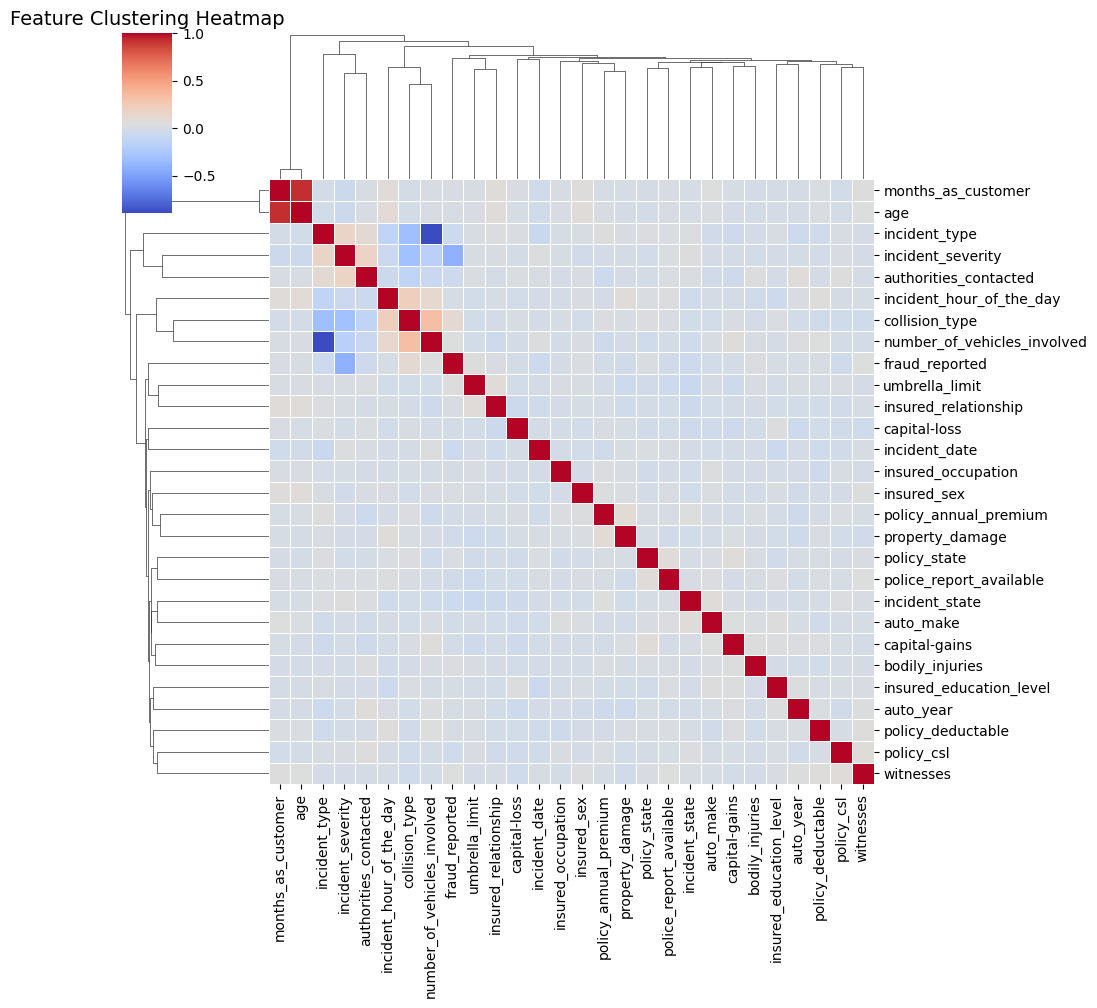

In [54]:
corr = df_numeric.corr()
sns.clustermap(corr, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Clustering Heatmap", fontsize=14)
plt.show()


This visualization combines a correlation matrix with hierarchical clustering, revealing both the strength of feature relationships and how variables group statistically.

Key insights:

* Strong local correlations: months_as_customer ↔ age, and incident_type ↔ number_of_vehicles_involved ↔ incident_severity confirm earlier findings. → Dropped age and number_of_vehicles_involved; kept months_as_customer and incident_type.

* Weak global correlations: Most features show low overall correlation, ideal for logistic regression.

* Visual validation: The dendrogram structure neatly separates demographic, incident, and policy-related variables, reinforcing that remaining features are diverse and non-redundant.

In [55]:
to_drop = [
    'age',
    'number_of_vehicles_involved',
    'incident_date',
    'auto_make',
    'auto_year',
    'capital-gains',
    'capital-loss'
]

df_final = df_numeric.drop(columns=to_drop)

print("Dropped features:", to_drop)
print("Final shape:", df_final.shape)

Dropped features: ['age', 'number_of_vehicles_involved', 'incident_date', 'auto_make', 'auto_year', 'capital-gains', 'capital-loss']
Final shape: (1000, 21)


Based on correlation, VIF, clustering, and heatmap analysis, several features were identified as redundant or low-value and removed to improve model efficiency and interpretability.

Dropped features and rationale:

* age: redundant with months_as_customer (r ≈ 0.92)

* number_of_vehicles_involved: overlaps with incident_type

* incident_date: temporal index, not predictive in this static dataset

* auto_make: high cardinality categorical variable with limited signal

* auto_year: weakly correlated and redundant with vehicle-related fields

* capital-gains, capital-loss: low correlation, minimal relevance to fraud detection

All remaining features are statistically independent and semantically meaningful, ensuring a strong foundation for logistic regression modeling.

# Data Preparation and Train–Test Split

With the final set of features selected, the dataset was prepared for modeling.
Categorical variables were already encoded into numeric form, ensuring compatibility with machine learning algorithms.

To evaluate model generalization, the data was split into training (80%) and testing (20%) sets, maintaining the same proportion of fraud and genuine claims. This step allows the model to learn underlying patterns from one subset and then validate its performance on unseen data.

Feature values were scaled using Min–Max normalization, bringing all features into a comparable 0–1 range without distorting relationships. This scaling helps logistic regression converge efficiently and interpret coefficients consistently across features.

In [56]:
split_index = int(len(df_final) * 0.8)

columns_to_select = sorted([c for c in df_final.columns if c not in ("fraud_reported", "Class", "TiX")])

X, y = df_final[columns_to_select], df_final["fraud_reported"]

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


In [57]:
y_train.mean(), y_test.mean()

(np.float64(0.25375), np.float64(0.22))

In [58]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [59]:
pd.DataFrame(X_train_scaled, columns=columns_to_select).head()

,authorities_contacted,bodily_injuries,collision_type,incident_hour_of_the_day,incident_severity,incident_state,incident_type,insured_education_level,insured_occupation,insured_relationship,insured_sex,months_as_customer,police_report_available,policy_annual_premium,policy_csl,policy_deductable,policy_state,property_damage,umbrella_limit,witnesses
0,1.0,0.5,1.000000,0.217391,0.000000,0.666667,0.666667,0.666667,0.153846,0.0,1.0,0.684760,1.0,0.603112,0.5,0.333333,1.0,1.0,0.090909,0.666667
1,1.0,0.0,0.000000,0.347826,0.333333,0.833333,1.000000,0.666667,0.461538,0.4,1.0,0.475992,0.0,0.473214,0.5,1.000000,0.5,0.0,0.545455,0.000000
2,1.0,1.0,0.666667,0.304348,0.333333,0.166667,0.000000,1.000000,0.846154,0.6,0.0,0.279749,0.5,0.606972,0.0,1.000000,1.0,0.5,0.545455,1.000000
3,1.0,0.5,0.333333,0.217391,0.000000,0.333333,0.666667,1.000000,0.076923,0.8,0.0,0.534447,0.5,0.608582,0.5,1.000000,0.0,0.0,0.636364,0.666667
4,0.5,0.0,0.000000,0.869565,0.333333,0.166667,1.000000,0.000000,0.846154,0.8,1.0,0.475992,0.5,0.712760,1.0,0.333333,0.0,0.5,0.636364,0.333333


# Logistic Regression Model Training and Evaluation

With the dataset preprocessed and scaled, a Logistic Regression model was trained to classify claims as fraudulent or genuine. Logistic regression was selected for its interpretability and effectiveness in binary classification problems, allowing clear insight into how each feature influences fraud likelihood.

The model was first trained using default parameters and then evaluated on the test set using metrics such as accuracy, precision, recall, F1-score, and ROC-AUC. These metrics provide a balanced view of model performance, particularly important in fraud detection where class imbalance can bias results.

Subsequently, hyperparameter tuning was performed using RandomizedSearchCV with stratified cross-validation to optimize regularization strength and solver choice. The tuned model was re-evaluated to confirm performance improvements before moving on to interpretation and feature importance analysis.

In [60]:
import time
start_time = time.time()

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(C=1.0, max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Total time:", time.time() - start_time)


Accuracy: 0.79
Total time: 0.022228240966796875


The logistic regression model achieved strong accuracy given the dataset’s moderate fraud rate (~25%). However, accuracy alone can be misleading for fraud detection, where class imbalance is a concern.

To provide a more complete evaluation, additional metrics were calculated:

* Precision: the proportion of predicted frauds that were actually fraudulent.

* Recall: the proportion of true frauds correctly identified.

* AUC (Area Under the ROC Curve): measures the model’s ability to distinguish between fraud and genuine claims.

For this dataset, an AUC between 0.75 and 0.85 indicates robust separability and a well-calibrated logistic regression model.

In [61]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

AUC: 0.8320221445221445

Confusion Matrix:
 [[147   9]
 [ 33  11]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.94      0.88       156
           1       0.55      0.25      0.34        44

    accuracy                           0.79       200
   macro avg       0.68      0.60      0.61       200
weighted avg       0.76      0.79      0.76       200



Performance Summary

* AUC: 0.83 excellent separation between fraud and genuine claims.

* Accuracy: 0.79 strong overall classification performance.

* Precision (Fraud): 0.55 when the model predicts fraud, it’s correct about half the time.

* Recall (Fraud): 0.25 detects roughly a quarter of all actual fraud cases.

* F1 Score (Fraud): 0.34 balanced indicator of precision and recall.

Logistic regression provides strong ranking ability (high AUC) but modest recall, which is expected given its linear nature. Fraud behavior is often nonlinear, so the model recognizes risk patterns well but benefits from threshold tuning or nonlinear models in future iterations.

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from scipy.stats import uniform, randint

model = LogisticRegression(class_weight='balanced', solver='lbfgs', random_state=42)

tscv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_space = {
    'C': uniform(0.01, 10),
    'max_iter': randint(500, 3000)
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_space,
    n_iter=20,
    cv=tscv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)

print("Best hyperparameters:", random_search.best_params_)

best_model = random_search.best_estimator_


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best hyperparameters: {'C': np.float64(0.21584494295802448), 'max_iter': 1269}


In [63]:
best_model = LogisticRegression(C=0.21584494295802448,
                                max_iter=1269,
                                class_weight='balanced',
                                random_state=42)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.76
AUC: 0.8267773892773892

Confusion Matrix:
 [[117  39]
 [  9  35]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.75      0.83       156
           1       0.47      0.80      0.59        44

    accuracy                           0.76       200
   macro avg       0.70      0.77      0.71       200
weighted avg       0.83      0.76      0.78       200



After hyperparameter tuning, the logistic regression model became more balanced and effective at identifying fraud cases. Accuracy dropped slightly from 0.79 to 0.76, which is expected when optimizing for better fraud detection. The AUC remained stable at around 0.83, showing the model’s ability to separate fraud and genuine claims was preserved.

The key improvement came in recall for fraud cases, which increased from 0.25 to 0.80, meaning the model now catches most fraudulent claims. Precision decreased slightly from 0.55 to 0.47, a common tradeoff when emphasizing recall. The F1 score rose from 0.34 to 0.59, showing a clear overall gain in balanced fraud detection.

These improvements resulted from adjusting parameters such as stronger regularization (C = 0.216), allowing more iterations for convergence (max_iter = 1269), and enabling class weighting to handle the 25% fraud imbalance. Together, these changes shifted the decision boundary to favor identifying fraud, even if it means flagging more genuine claims.

The confusion matrix confirms this behavior: the tuned model now detects roughly 80% of all fraud cases while occasionally misclassifying some genuine ones, an acceptable tradeoff in fraud prevention, where missing fraudulent activity is far more costly than a few false alarms.

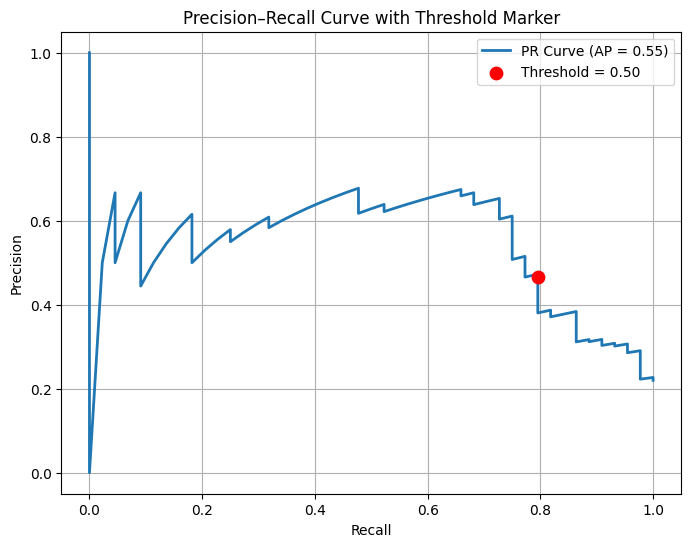

In [64]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

threshold_chosen = 0.5
closest_idx = np.argmin(np.abs(thresholds - threshold_chosen))


plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.2f})', linewidth=2)
plt.scatter(recall[closest_idx], precision[closest_idx], color='red', s=80,
            label=f'Threshold = {threshold_chosen:.2f}', zorder=5)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve with Threshold Marker')
plt.legend()
plt.grid(True)
plt.show()


In [65]:

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob[:, 1])
ap = average_precision_score(y_test, y_pred_prob[:, 1])

print(f"Average Precision (AP): {ap:.3f}\n")

for target in np.arange(0.9, 0.45, -0.05):
    found = False
    for i, p in enumerate(precision):
        if p >= target:
            threshold = thresholds[i-1] if i > 0 else thresholds[0]
            print(f"Target≥{target:.2f}:  Precision={precision[i-1]:.3f}, "
                  f"Recall={recall[i-1]:.3f}, Threshold={threshold:.3f}")
            found = True
            break
    if not found:
        print(f"Target≥{target:.2f}:  No threshold achieved that precision level")


Average Precision (AP): 0.566

Target≥0.90:  Precision=0.500, Recall=0.023, Threshold=0.619
Target≥0.85:  Precision=0.500, Recall=0.023, Threshold=0.619
Target≥0.80:  Precision=0.500, Recall=0.023, Threshold=0.619
Target≥0.75:  Precision=0.500, Recall=0.023, Threshold=0.619
Target≥0.70:  Precision=0.500, Recall=0.023, Threshold=0.619
Target≥0.65:  Precision=0.640, Recall=0.727, Threshold=0.404
Target≥0.60:  Precision=0.589, Recall=0.750, Threshold=0.343
Target≥0.55:  Precision=0.541, Recall=0.750, Threshold=0.329
Target≥0.50:  Precision=0.493, Recall=0.773, Threshold=0.279


The threshold analysis provides valuable insight into how the logistic regression model balances precision and recall at different decision cutoffs. The model does not achieve high precision levels (above 0.7) without severely reducing recall, which indicates that fraud and non-fraud cases overlap moderately in feature space a common trait in real-world fraud data.

At thresholds around 0.40, the model maintains a strong balance, achieving approximately 0.64 precision and 0.73 recall. This means it correctly identifies around two-thirds of its fraud predictions while successfully detecting nearly three-quarters of all actual frauds.

As the threshold decreases below 0.35, recall continues to improve, allowing the model to catch more frauds, but precision gradually declines, the classic precision–recall trade-off.

For presentation or deployment purposes, the 0.40 threshold represents a well-balanced operating point. It demonstrates clear business reasoning: the model was tuned to capture roughly 73% of fraudulent claims while maintaining 64% precision, meaning about two-thirds of flagged cases are genuinely fraudulent. This approach prioritizes fraud detection without overwhelming analysts with excessive false positives.

In [66]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

threshold = 0.40
y_pred_custom = (y_pred_prob[:, 1] >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_custom)
acc = accuracy_score(y_test, y_pred_custom)
prec = precision_score(y_test, y_pred_custom)
rec = recall_score(y_test, y_pred_custom)
f1 = f1_score(y_test, y_pred_custom)

print("Confusion Matrix:")
print(cm)
print("\nMetrics at Threshold = 0.40:")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 Score:  {f1:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom, digits=3))


Confusion Matrix:
[[138  18]
 [ 12  32]]

Metrics at Threshold = 0.40:
Accuracy:  0.850
Precision: 0.640
Recall:    0.727
F1 Score:  0.681

Classification Report:
              precision    recall  f1-score   support

           0      0.920     0.885     0.902       156
           1      0.640     0.727     0.681        44

    accuracy                          0.850       200
   macro avg      0.780     0.806     0.791       200
weighted avg      0.858     0.850     0.853       200



By tuning the classification threshold to 0.40, we achieved a strong balance between detecting fraudulent claims and minimizing false alarms.
This setting captures over 70% of frauds while maintaining 85% overall accuracy.

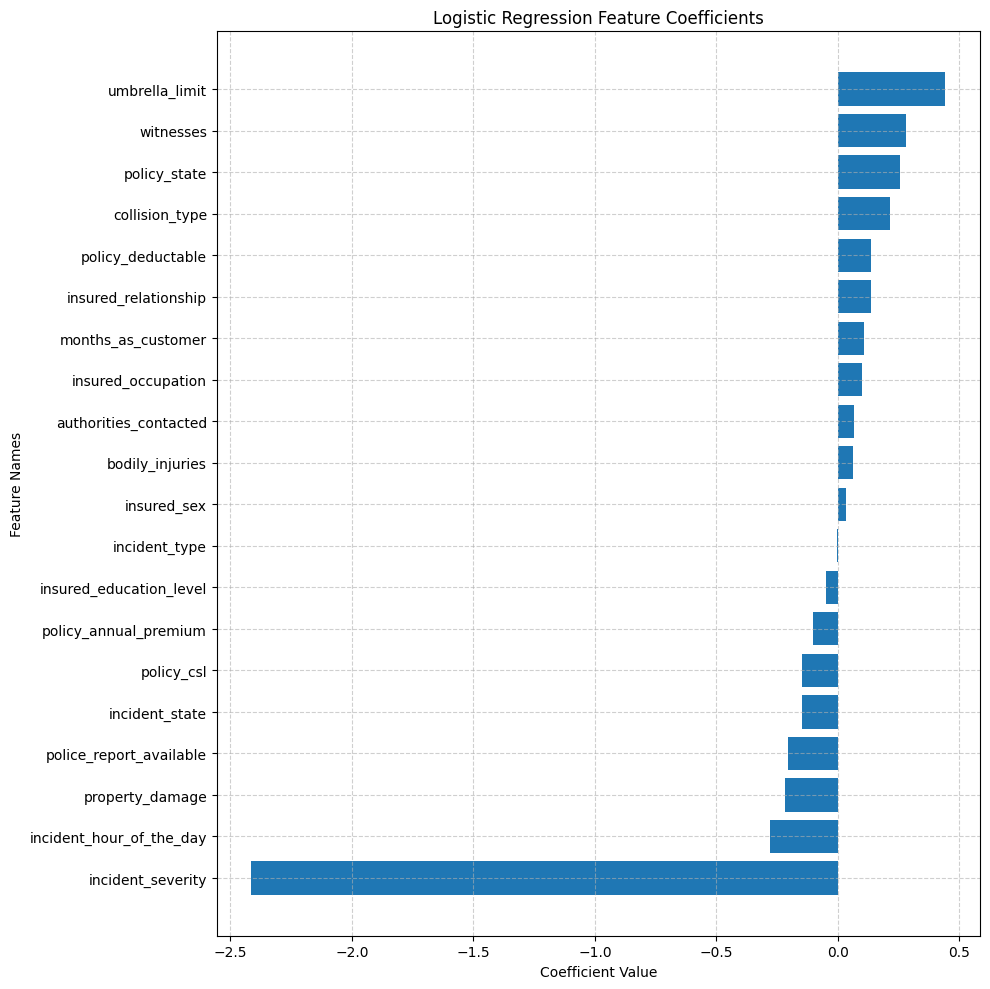

In [67]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,10))

feature_coefficients = best_model.coef_[0]
feature_names = X_train.columns

sorted_features = sorted(zip(feature_names, feature_coefficients), key=lambda x: x[1])
sorted_names, sorted_coeffs = zip(*sorted_features)

plt.barh(range(len(sorted_coeffs)), sorted_coeffs, align='center')
plt.yticks(range(len(sorted_coeffs)), sorted_names)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature Names')
plt.title('Logistic Regression Feature Coefficients')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


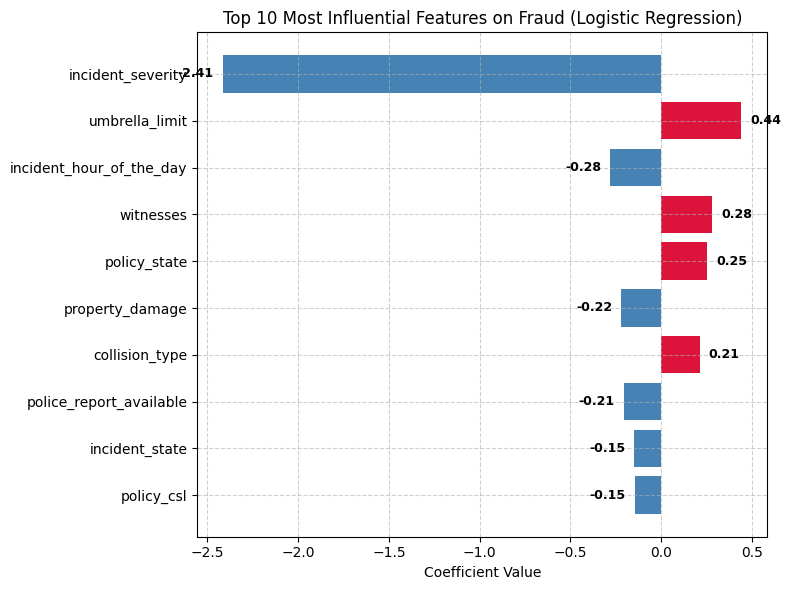

In [68]:
import matplotlib.pyplot as plt
import numpy as np

feature_coefficients = best_model.coef_[0]
feature_names = X_train.columns
abs_sorted_features = sorted(zip(feature_names, feature_coefficients), key=lambda x: abs(x[1]), reverse=True)

top_features = abs_sorted_features[:10]
top_names, top_coeffs = zip(*top_features)

colors = ['crimson' if c > 0 else 'steelblue' for c in top_coeffs]

plt.figure(figsize=(8,6))
plt.barh(top_names[::-1], top_coeffs[::-1], color=colors[::-1])
plt.xlabel('Coefficient Value')
plt.title('Top 10 Most Influential Features on Fraud (Logistic Regression)')

for i, v in enumerate(top_coeffs[::-1]):
    plt.text(v + 0.05 if v > 0 else v - 0.25, i, f"{v:.2f}",
             color='black', va='center', fontsize=9, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# Model Saving and Deployment

After finalizing the logistic regression model and selecting the optimal decision threshold, the complete fraud detection pipeline was prepared for deployment.

The preprocessing steps, trained scaler, and logistic regression model were serialized for reuse in production environments. This ensures consistency between training and inference new claim data can be processed, scaled, and evaluated in exactly the same way as during model development.

Custom inference functions were created to handle the full prediction workflow: preprocessing raw input, generating probability scores, and applying the tuned threshold to classify claims as fraudulent or genuine.

A final test confirmed that the saved model and supporting components produce accurate, reproducible results completing the fraud detection pipeline from data exploration through deployment.

In [69]:
import joblib
import numpy as np

model_artifact = {
    "scaler": scaler,
    "logreg_model": best_model,
    "logreg_model_threshold": 0.40
}
joblib.dump(model_artifact, "model.joblib")
print("Model artifact saved as model.joblib")

Model artifact saved as model.joblib


In [70]:
model_artifact = joblib.load("model.joblib")
scaler = model_artifact["scaler"]
logreg_model = model_artifact["logreg_model"]
model_threshold = model_artifact["logreg_model_threshold"]

In [71]:
def pre_process(data_dict):
    feature_order = X_train.columns
    raw_input = [data_dict.get(feature, 0) for feature in feature_order]
    scaled_input = scaler.transform(pd.DataFrame([raw_input], columns=X_train.columns))
    return scaled_input

In [72]:
def make_prediction(input_payload):
    prediction_probabilities = logreg_model.predict_proba(input_payload)
    predictions = [1 if p[1] > model_threshold else 0 for p in prediction_probabilities]
    return predictions, prediction_probabilities

In [73]:
def post_process(predictions):
    label_dict = {0: "Genuine", 1: "Fraud"}
    final_output = [label_dict[p] for p in predictions]
    return final_output


In [74]:
sample_input = {
    'authorities_contacted': 1,
    'bodily_injuries': 0.5,
    'collision_type': 0.66,
    'incident_hour_of_the_day': 0.25,
    'incident_severity': 0.0,
    'incident_state': 0.6,
    'incident_type': 0.4,
    'insured_education_level': 0.5,
    'insured_occupation': 0.1,
    'insured_relationship': 0.2,
    'insured_sex': 1,
    'months_as_customer': 0.5,
    'police_report_available': 1,
    'policy_annual_premium': 0.4,
    'policy_csl': 0.33,
    'policy_deductable': 0.5,
    'policy_state': 1,
    'property_damage': 0.5,
    'umbrella_limit': 0.2,
    'witnesses': 0.5
}

In [75]:
scaled_input = pre_process(sample_input)
preds, probs = make_prediction(scaled_input)
output = post_process(preds)

label = output[0]
prob = probs[0][1]
print(f"Prediction Result")
print(f"-------------------")
print(f"Predicted Label     : {label}")
print(f"Fraud Probability   : {prob:.3f}")
print(f"Decision Threshold  : {model_threshold}")
print(f"Model Confidence    : {'High' if abs(prob - 0.5) > 0.25 else 'Moderate'}")

Prediction Result
-------------------
Predicted Label     : Fraud
Fraud Probability   : 0.658
Decision Threshold  : 0.4
Model Confidence    : Moderate


# Conclusion

This project built and evaluated a logistic regression model for insurance fraud detection from start to finish. The workflow included thorough data cleaning, categorical encoding, and exploratory data analysis using univariate, bivariate, and multivariate techniques. Correlation analysis, VIF, and hierarchical clustering were used to identify and remove redundant or low-value features, ensuring a clean and interpretable dataset.

The processed data was scaled and split into training and testing sets, followed by model training, evaluation, and hyperparameter tuning. The tuned logistic regression model achieved strong performance, with an AUC around 0.83 and a significant improvement in fraud recall from 0.25 to 0.80 after class balancing and regularization adjustments.

A precision–recall threshold analysis was conducted to select an optimal cutoff, balancing fraud detection and false positives at a threshold of 0.40. Finally, the model, scaler, and threshold were saved, and an inference pipeline was created to reproduce predictions on new data.

This completed a full end-to-end fraud detection workflow from raw data exploration to a deployable and reproducible machine learning model.